## Lab 2
### Part 2: Dealing with overfitting

Today we work with [Fashion-MNIST dataset](https://github.com/zalandoresearch/fashion-mnist) (*hint: it is available in `torchvision`*).

Your goal for today:
1. Train a FC (fully-connected) network that achieves >= 0.885 test accuracy.
2. Cause considerable overfitting by modifying the network (e.g. increasing the number of network parameters and/or layers) and demonstrate in in the appropriate way (e.g. plot loss and accurasy on train and validation set w.r.t. network complexity).
3. Try to deal with overfitting (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

__Please, write a small report describing your ideas, tries and achieved results in the end of this file.__

*Note*: Tasks 2 and 3 are interrelated, in task 3 your goal is to make the network from task 2 less prone to overfitting. Task 1 is independent from 2 and 3.

*Note 2*: We recomment to use Google Colab or other machine with GPU acceleration.

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchsummary
from IPython.display import clear_output
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import os


device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [3]:
# Technical function
def mkdir(path):
    if not os.path.exists(root_path):
        os.mkdir(root_path)
        print('Directory', path, 'is created!')
    else:
        print('Directory', path, 'already exists!')

root_path = 'fmnist'
mkdir(root_path)

Directory fmnist is created!


In [4]:
download = True
train_transform = transforms.ToTensor()
test_transform = transforms.ToTensor()
transforms.Compose((transforms.ToTensor()))


fmnist_dataset_train = torchvision.datasets.FashionMNIST(root_path,
                                                        train=True,
                                                        transform=train_transform,
                                                        target_transform=None,
                                                        download=download)
fmnist_dataset_test = torchvision.datasets.FashionMNIST(root_path,
                                                       train=False,
                                                       transform=test_transform,
                                                       target_transform=None,
                                                       download=download)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.1MB/s]


Extracting fmnist/FashionMNIST/raw/train-images-idx3-ubyte.gz to fmnist/FashionMNIST/raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 353kB/s]


Extracting fmnist/FashionMNIST/raw/train-labels-idx1-ubyte.gz to fmnist/FashionMNIST/raw



100%|██████████| 4.42M/4.42M [00:00<00:00, 6.14MB/s]


Extracting fmnist/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to fmnist/FashionMNIST/raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 5.14MB/s]

Extracting fmnist/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to fmnist/FashionMNIST/raw



In [5]:
fmnist_dataset_train

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: fmnist
    Split: Train
    StandardTransform
Transform: ToTensor()

In [6]:
train_loader = torch.utils.data.DataLoader(fmnist_dataset_train,
                                           batch_size=128,
                                           shuffle=True,
                                           num_workers=2)
test_loader = torch.utils.data.DataLoader(fmnist_dataset_test,
                                          batch_size=256,
                                          shuffle=False,
                                          num_workers=2)

In [7]:
for img, label in train_loader:
    print(img.shape)
#     print(img)
    print(label.shape)
    print(label.size(0))
    break

torch.Size([128, 1, 28, 28])
torch.Size([128])
128


### Task 1
Train a network that achieves $\geq 0.885$ test accuracy. It's fine to use only Linear (`nn.Linear`) layers and activations/dropout/batchnorm. Convolutional layers might be a great use, but we will meet them a bit later.

In [ ]:
class TinyNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_shape, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [ ]:
torchsummary.summary(TinyNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 128]         100,480
       BatchNorm1d-3                  [-1, 128]             256
              ReLU-4                  [-1, 128]               0
            Linear-5                   [-1, 10]           1,290
Total params: 102,026
Trainable params: 102,026
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.39
Estimated Total Size (MB): 0.40
----------------------------------------------------------------


Your experiments come here:

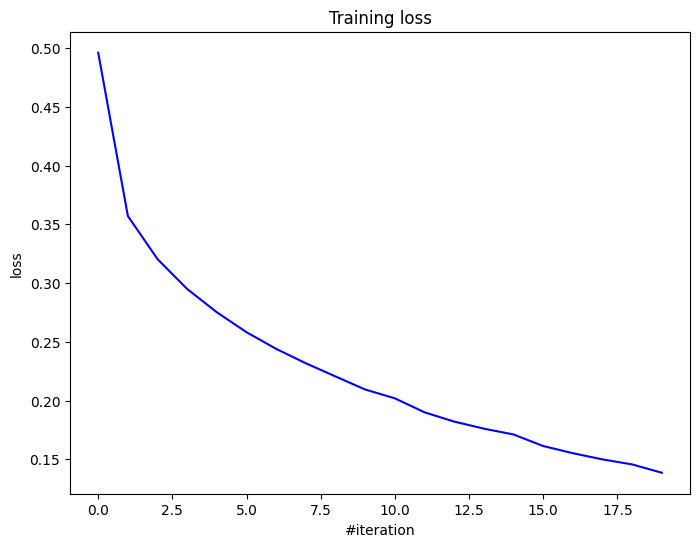

Current loss: 0.138600


In [ ]:
model = TinyNeuralNetwork().to(device)
opt = optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.CrossEntropyLoss()

loss_history = []

for epoch in range(20):
    losses = []

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        opt.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        opt.step()
        losses.append(loss.cpu().detach().numpy())

    loss_history.append(np.mean(losses))

    # Visualize
    clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    plt.title("Training loss")
    plt.xlabel("#iteration")
    plt.ylabel("loss")
    plt.plot(loss_history, 'b')
    plt.show()

    print('Current loss: %f' % loss_history[-1])

In [ ]:
correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = correct / total
print(f'Test Accuracy at epoch {epoch+1}: {test_accuracy}')

Test Accuracy at epoch 20: 0.8837


### Task 2: Overfit it.
Build a network that will overfit to this dataset. Demonstrate the overfitting in the appropriate way (e.g. plot loss and accurasy on train and test set w.r.t. network complexity).

*Note:* you also might decrease the size of `train` dataset to enforce the overfitting and speed up the computations.

In [8]:
class OverfittingNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            nn.Linear(input_shape, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out;

In [9]:
torchsummary.summary(OverfittingNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                 [-1, 1024]         525,312
              ReLU-5                 [-1, 1024]               0
            Linear-6                  [-1, 512]         524,800
              ReLU-7                  [-1, 512]               0
            Linear-8                  [-1, 128]          65,664
              ReLU-9                  [-1, 128]               0
           Linear-10                  [-1, 256]          33,024
             ReLU-11                  [-1, 256]               0
           Linear-12                   [-1, 10]           2,570
Total params: 1,553,290
Trainable params: 1,553,290
Non-trainable params: 0
---------------------------

In [10]:
subset_size = 5000

subset_indices = list(range(subset_size))
train_subset = torch.utils.data.Subset(fmnist_dataset_train, subset_indices)

train_loader_small = torch.utils.data.DataLoader(train_subset, batch_size=128, shuffle=True)

<Figure size 800x600 with 0 Axes>

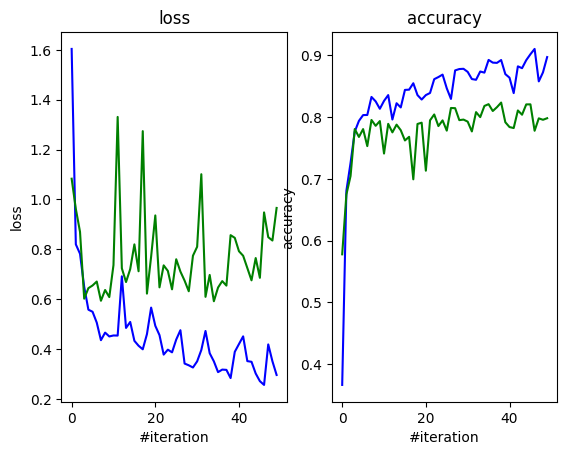

Current train loss: 0.295938
Current test loss: 0.965823
Current train accuracy: 0.897400
Current test accuracy: 0.798300


In [11]:
model = OverfittingNeuralNetwork().to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
loss_func = nn.CrossEntropyLoss()

loss_history_train = []
loss_history_test = []
accuracy_history_train = []
accuracy_history_test = []

for epoch in range(50):
    losses_train = []
    losses_test = []
    correct, total, total_train, correct_train = 0,0,0,0

    for i, (images, labels) in enumerate(train_loader_small):
        images = images.to(device)
        labels = labels.to(device)
        opt.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        opt.step()
        losses_train.append(loss.cpu().detach().numpy())
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = correct_train / total_train
    accuracy_history_train.append(train_accuracy)
    loss_history_train.append(np.mean(losses_train))

    with torch.no_grad():
      for images, labels in test_loader:
          images = images.to(device)
          labels = labels.to(device)
          outputs = model(images)
          loss = loss_func(outputs, labels)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
          losses_test.append(loss.cpu().detach().numpy())

      loss_history_test.append(np.mean(losses_test))
      test_accuracy = correct / total
      accuracy_history_test.append(test_accuracy)


    # Visualize
    clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    f, (ax1, ax2) = plt.subplots(1, 2)
    ax1.set_title("loss")
    ax1.set_xlabel("#iteration")
    ax1.set_ylabel("loss")
    ax1.plot(loss_history_train, 'b')
    ax1.plot(loss_history_test, 'g')

    ax2.set_title("accuracy")
    ax2.set_xlabel("#iteration")
    ax2.set_ylabel("accuracy")
    ax2.plot(accuracy_history_train, 'b')
    ax2.plot(accuracy_history_test, 'g')

    plt.show()

    print('Current train loss: %f' % loss_history_train[-1])
    print('Current test loss: %f' % loss_history_test[-1])
    print('Current train accuracy: %f' % accuracy_history_train[-1])
    print('Current test accuracy: %f' % accuracy_history_test[-1])

### Task 3: Fix it.
Fix the overfitted network from the previous step (at least partially) by using regularization techniques (Dropout/Batchnorm/...) and demonstrate the results.

In [12]:
class FixedNeuralNetwork(nn.Module):
    def __init__(self, input_shape=28*28, num_classes=10, input_channels=1):
        super(self.__class__, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(), # This layer converts image into a vector to use Linear layers afterwards
            nn.Linear(input_shape, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, inp):
        out = self.model(inp)
        return out

In [20]:
torchsummary.summary(FixedNeuralNetwork().to(device), (28*28,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
       BatchNorm1d-3                  [-1, 512]           1,024
              ReLU-4                  [-1, 512]               0
           Dropout-5                  [-1, 512]               0
            Linear-6                  [-1, 256]         131,328
              ReLU-7                  [-1, 256]               0
           Dropout-8                  [-1, 256]               0
            Linear-9                  [-1, 128]          32,896
             ReLU-10                  [-1, 128]               0
          Dropout-11                  [-1, 128]               0
           Linear-12                   [-1, 64]           8,256
             ReLU-13                   [-1, 64]               0
          Dropout-14                   

<Figure size 800x600 with 0 Axes>

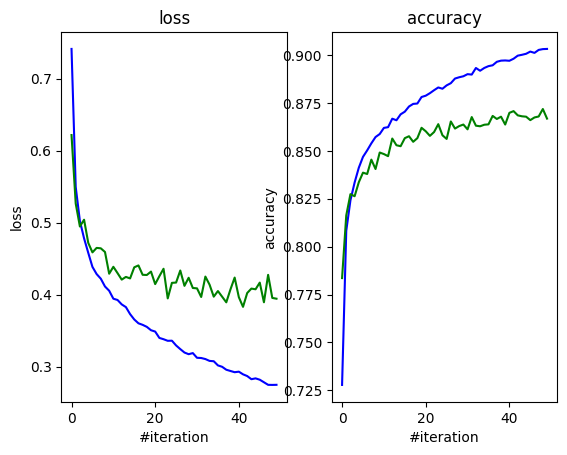

Current train loss: 0.274928
Current test loss: 0.394475
Current train accuracy: 0.903150
Current test accuracy: 0.866800


In [13]:
model = FixedNeuralNetwork().to(device)
opt = optim.Adam(model.parameters(), lr=0.01)
loss_func = nn.CrossEntropyLoss()

loss_history_train = []
loss_history_test = []
accuracy_history_train = []
accuracy_history_test = []

for epoch in range(50):
    losses_train = []
    losses_test = []
    correct, total, total_train, correct_train = 0,0,0,0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        opt.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, labels)
        loss.backward()
        opt.step()
        losses_train.append(loss.cpu().detach().numpy())
        _, predicted = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_accuracy = correct_train / total_train
    accuracy_history_train.append(train_accuracy)
    loss_history_train.append(np.mean(losses_train))

    with torch.no_grad():
      for images, labels in test_loader:
          images = images.to(device)
          labels = labels.to(device)
          outputs = model(images)
          loss = loss_func(outputs, labels)
          _, predicted = torch.max(outputs, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()
          losses_test.append(loss.cpu().detach().numpy())

      loss_history_test.append(np.mean(losses_test))
      test_accuracy = correct / total
      accuracy_history_test.append(test_accuracy)


    # Visualize
    clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    f, (ax1, ax2) = plt.subplots(1, 2)
    ax1.set_title("loss")
    ax1.set_xlabel("#iteration")
    ax1.set_ylabel("loss")
    ax1.plot(loss_history_train, 'b')
    ax1.plot(loss_history_test, 'g')

    ax2.set_title("accuracy")
    ax2.set_xlabel("#iteration")
    ax2.set_ylabel("accuracy")
    ax2.plot(accuracy_history_train, 'b')
    ax2.plot(accuracy_history_test, 'g')

    plt.show()

    print('Current train loss: %f' % loss_history_train[-1])
    print('Current test loss: %f' % loss_history_test[-1])
    print('Current train accuracy: %f' % accuracy_history_train[-1])
    print('Current test accuracy: %f' % accuracy_history_test[-1])

### Conclusions:
_Write down small report with your conclusions and your ideas._

Сначала написали простую модель в 1 шаг, где использовали батч нормализацию и немного линейных слоев, получились достаточно неплохие результаты.

Затем во втором шаге уменьшили размер выборки до 5000, поставили 50 эпох и в модели добавили куча линейных слоев, чтобы вызвать переобучение.
Как мы увидели на графике, тестовый и трейн лосс в моменте начинаются сильно расходится, где лосс теста начинается увеличиваться, а лосс треин начинает уменьшаться, причем аккураси неплохое в обоих случаях. То что у теста с каждой эпохи лосс становится все больше означает, что наша модель все хуже предсказывает тестовые результаты, так как не стремится уменьшать ошибку

В третьем шаги добавили для регуляризации нормализацию и дропауты в каждом слое, в итоге видим как у нас тест лосс начинает стабилизироваться и следовать около треин лосса (разница заключается в том, что у нас все же не прям идентичные данные). Также взяли всю выборку вместо обрезанной.

Также из выводов можно сделать, что перебарщивать c dropout ведет к тому, что у нас модель вообще перестает учиться, так что нужно быть с этим аккуратнее.